In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


In [53]:
class MyLR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self,x_train,y_train):
        num = 0
        den = 0

        for i in range(x_train.shape[0]):
            num = num + ((x_train[i] - x_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((x_train[i] - x_train.mean())*(x_train[i] - x_train.mean()))

        self.m = num/den
        self.b = y_train.mean() - (self.m*x_train.mean())
        print(self.m)
        print(self.b)
    def predict(self,x_test):

        print(x_test)

        return self.m*x_test + self.b
    

In [54]:
df = pd.read_csv('/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv')

In [55]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [56]:
df = df.iloc[:,1:]
df.sample(5)

,YearsExperience,Salary
2,1.6,37732.0
22,8.0,101303.0
25,9.1,105583.0
21,7.2,98274.0
13,4.2,57082.0


In [57]:
x = df.iloc[:,0].values
y = df.iloc[:,-1].values

In [58]:
x

array([ 1.2,  1.4,  1.6,  2.1,  2.3,  3. ,  3.1,  3.3,  3.3,  3.8,  4. ,
        4.1,  4.1,  4.2,  4.6,  5. ,  5.2,  5.4,  6. ,  6.1,  6.9,  7.2,
        8. ,  8.3,  8.8,  9.1,  9.6,  9.7, 10.4, 10.6])

In [59]:
y

array([ 39344.,  46206.,  37732.,  43526.,  39892.,  56643.,  60151.,
        54446.,  64446.,  57190.,  63219.,  55795.,  56958.,  57082.,
        61112.,  67939.,  66030.,  83089.,  81364.,  93941.,  91739.,
        98274., 101303., 113813., 109432., 105583., 116970., 112636.,
       122392., 121873.])

In [60]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [61]:
lr = MyLR()

In [62]:
lr.fit(x_train,y_train)

9569.586885432866
23437.21046340505


In [63]:
x_test[0]

np.float64(1.4)

In [64]:
y_test[0]

np.float64(46206.0)

In [65]:
print(lr.predict(x_test[0]))

1.4
36834.632103011056


In [66]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [68]:
y_pred = lr.predict(x_test)

[1.4 1.2 4.6 3.8 7.2 6.1]


In [71]:
y_test

array([46206., 39344., 61112., 57190., 98274., 93941.])

In [72]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 6802.779572073905


In [73]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 56137509.99782566


In [74]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 7492.49691343451


In [75]:
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score 0.8886956733784561


In [78]:
# Adjusted R2 score
x_test.shape

(6,)

In [79]:
1 - ((1-r2)*(6-1)/(6-1-1))

0.8608695917230702

[ 8.3  3.1  2.1  6.9  3.   9.7  4.1  2.3  4.   5.2 10.4  9.1  5.4  1.6
  3.3  9.6  8.8  6.   4.1  8.  10.6  4.2  5.   3.3]


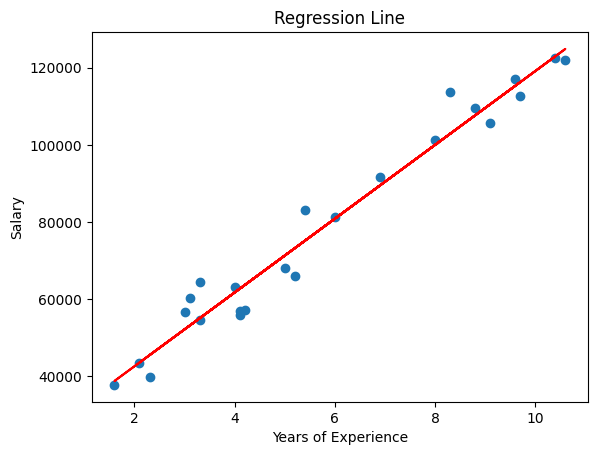

In [80]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train)
plt.plot(x_train, lr.predict(x_train), color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Regression Line")
plt.show()

In [83]:
# compare with sklearn model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train.reshape(-1, 1), y_train)

print("Sklearn R2:", model.score(x_test.reshape(-1,1), y_test))

Sklearn R2: 0.8886956733784561
